# Neural Networks

This notebook aims to introduce the perceptron algorithm and feed-forward neural networks for classification and regression problems.

## Classification of non-linearly separable dataset using multi-layer perceptron

Past sessions have studied linear separability and how different classification problems can be solved with linear models!

If however the data is not linearly separable, we may need more complex models for learning to make accurate predictions. Let's start our demonstration by building a neural network model using PyTorch and use it to classify a toy data set which is not linearly separable.

Please:

* Make sure that you copy the *entire* folder to your Drive.
* Work in small groups (course assistants will join to help guide discussion!)
* Discuss your reasoning with each other.
* Write short answers in the markdown cells provided.

In [33]:
import random
import torch
from torch import nn, optim
import math
from IPython import display

In [34]:
from google.colab import drive
drive.mount('/content/gdrive/')
import sys
sys.path.append('/content/gdrive/MyDrive/ML473/recitation/') ### CHANGE THIS TO YOUR PATH ###

# some predefined helper functions provided for plotting data and model outputs
from plot_lib import plot_data, plot_model, set_default


Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [35]:
set_default()

In [36]:
seed = 12345
random.seed(seed)
torch.manual_seed(seed)
N = 1000  # num_samples_per_class
D = 2     # dimensions
C = 3     # num_classes
H = 100   # num_hidden_units

### Create the dataset
We will now create a data set consisting of three classes and is in the shape of a spiral. This data will help illustrate some of the magic of neural networks!

In [37]:
X = torch.zeros(N * C, D)
y = torch.zeros(N * C, dtype=torch.long)
for c in range(C):
    index = 0
    t = torch.linspace(0, 1, N)
    # When c = 0 and t = 0: start of linspace
    # When c = 0 and t = 1: end of linpace
    # This inner_var is for the formula inside sin() and cos() like sin(inner_var) and cos(inner_Var)
    inner_var = torch.linspace(
        # When t = 0
        (2 * math.pi / C) * (c),
        # When t = 1
        (2 * math.pi / C) * (2 + c),
        N
    ) + torch.randn(N) * 0.2

    for ix in range(N * c, N * (c + 1)):
        X[ix] = t[index] * torch.FloatTensor((
            math.sin(inner_var[index]), math.cos(inner_var[index])
        ))
        y[ix] = c
        index += 1

print("Shapes:")
print("X:", tuple(X.size()))
print("y:", tuple(y.size()))

Shapes:
X: (3000, 2)
y: (3000,)


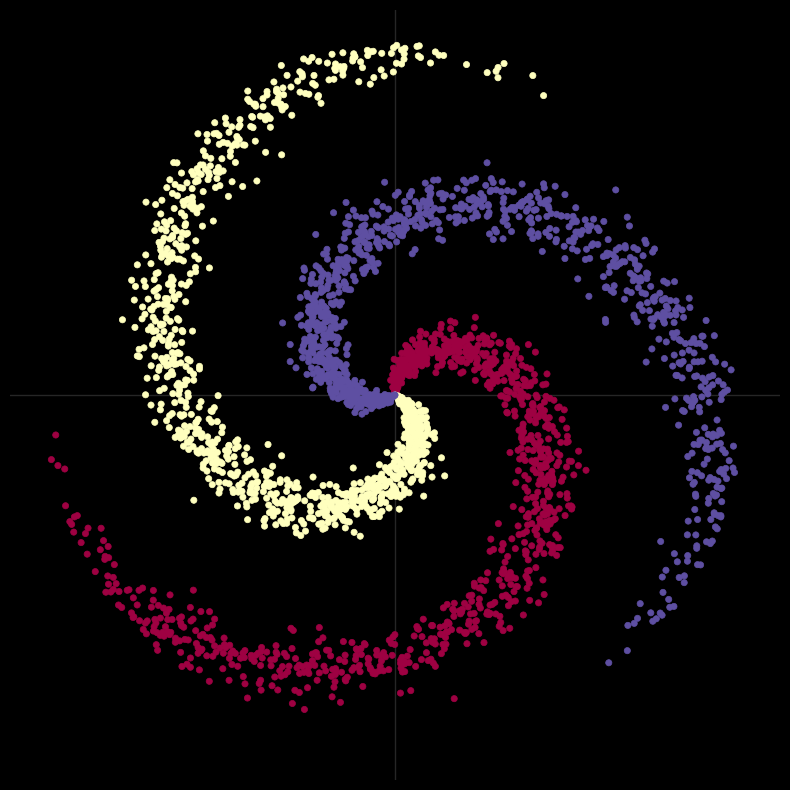

In [7]:
# visualise the data using the plot_data function provided as a helper function
plot_data(X, y)

**Discussion**
1. In one sentence, define linear separability.
2. Without training, predict: can a linear model separate a 3-arm spiral? Why or why not?
3. What if we instantiate a model with two linear layers? Can it now separate the spiral?
4. When might you have non-linearly separable data? Can you name some applications?

*Answer here*

### Linear Model
Okay, now let's test our prediction! We'll now define a linear classification model using PyTorch and train it using stochastic gradient descent with the help of the autograd package.

Let's start by initializing the hyper-parameter values such as the learning rate, regularization coefficient etc.

In [8]:
learning_rate = 1e-3
steps = 1000 # num. of training steps

Create the linear model (two linear layers) and print it.

In [10]:
# nn package to create our linear model. Notice the Sequential container class.
# Each Linear module has a weight and bias
# The order in which the Linear modules are defined is important as it creates the directed acyclic graph
model = nn.Sequential(
    nn.Linear(D, H),
    nn.Linear(H, C)
)

# Print the model
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=100, bias=True)
  (1): Linear(in_features=100, out_features=3, bias=True)
)


Create the training loop and print the metrics (loss and accuracy) at the end of each iteration.

In [11]:
# nn package has a variety of loss functions already implemented
# we use cross entropy loss for our classification task
criterion = torch.nn.CrossEntropyLoss()

# nn package also has a variety of optimization algorithms implemented
# we use the stochastic gradient descent for our parameter updates
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Training loop
for t in range(steps):

    # Forward pass over the model to get the logits
    y_pred = model(X)

    # Compute the loss and accuracy
    loss = criterion(y_pred, y)
    score, predicted = torch.max(y_pred, 1)
    acc = (y == predicted).sum().float() / len(y)
    print("[EPOCH]: %i, [LOSS]: %.6f, [ACCURACY]: %.3f" % (t, loss.item(), acc))
    display.clear_output(wait=True)

    # reset (zero) the gradients before running the backward pass over the model
    # we need to do this because the gradients get accumulated at the same place across iterations
    optimizer.zero_grad()

    # Backward pass to compute the gradient of loss w.r.t our learnable params (weights and biases)
    loss.backward()

    # Update params
    optimizer.step()

[EPOCH]: 999, [LOSS]: 0.873479, [ACCURACY]: 0.509


We can now plot the output of the model (in this case a collection of hyper-planes):

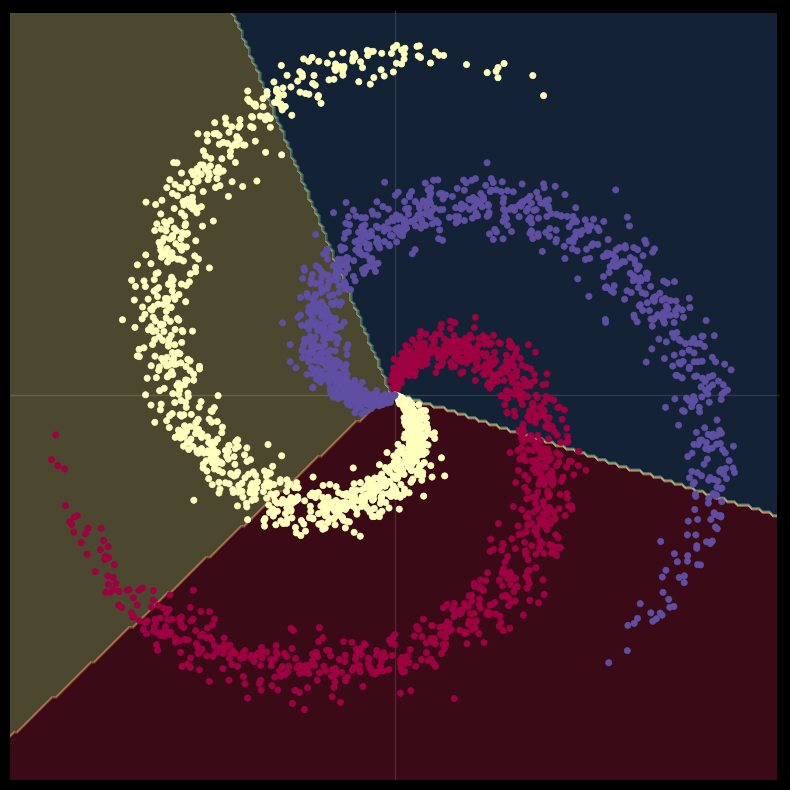

In [12]:
# Plot trained model
plot_model(X, y, model)

**Discussion**


1.   Was your prediction above correct? Why or why not?
2.  Brainstorm some ways that you could get a model to separate the spiral. Is it something that LLMs can do? :)
3. Discuss any issues with the network architecture. What would you fix first?



### Introducing Non-Linearity


We now define a two layer (single hidden layer) neural network model using PyTorch and train it using stochastic gradient descent with the help of the autograd package.

We will extend our linear model with ReLU as the activation units to create a multi-layer perceptron.

**Discussion**


1. What is ReLU?
2. Write a quick one or two sentence about why introducing a non-linearity through the activation function would help us fix the model. What does the non-linearity enable us to do?
3.   Before running the code, predict: do you think that this model will enable us to separate the spiral? Why or why not?



In [13]:
# Initialize the hyper-parameters
learning_rate = 1e-3

# nn package to create our linear model
# each Linear module has a weight and bias

model = nn.Sequential(
    nn.Linear(D, H),
    nn.ReLU(),
    nn.Linear(H, C)
)

print(model)

Sequential(
  (0): Linear(in_features=2, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=3, bias=True)
)


Let's use the new model to perform the classification task on the same data set and observe the accuracy.

In [14]:
# nn package has a variety of loss functions already implemented
# we use cross entropy loss for our classification task
criterion = torch.nn.CrossEntropyLoss()

# nn package also has a variety of optimization algorithms implemented
# we use the stochastic gradient descent for our parameter updates
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Training
for t in range(steps):

    # Forward pass over the model to get the logits
    y_pred = model(X)

    # Compute the loss and accuracy
    loss = criterion(y_pred, y)
    score, predicted = torch.max(y_pred, 1)
    acc = (y == predicted).sum().float() / len(y)
    print("[EPOCH]: %i, [LOSS]: %.6f, [ACCURACY]: %.3f" % (t, loss.item(), acc))
    display.clear_output(wait=True)

    # reset (zero) the gradients before running the backward pass over the model
    # we need to do this because the gradients get accumulated at the same place across iterations
    optimizer.zero_grad()

    # Backward pass to compute the gradient of loss w.r.t our learnable params (weights and biases)
    loss.backward()

    # Update params
    optimizer.step()

[EPOCH]: 999, [LOSS]: 0.936524, [ACCURACY]: 0.507


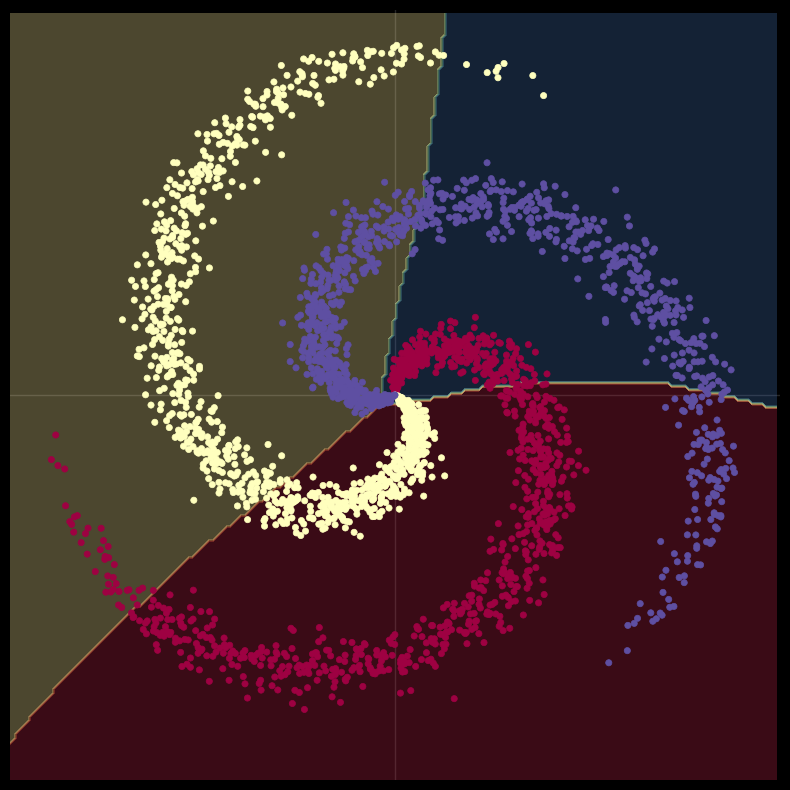

In [16]:
# Plot trained model
plot_model(X, y, model)

That doesn't quite split it! In the next exercise, you'll work on getting the network to split the spiral.

## Exercise 1

Experiment with the perceptron model by adding more hidden layers to the nn.Sequential module, such that there are more linear layers and activations to better extract more information useful for classification. Note that in between hidden layers we typically use Tanh activations (available in PyTorch as nn.Tanh()).

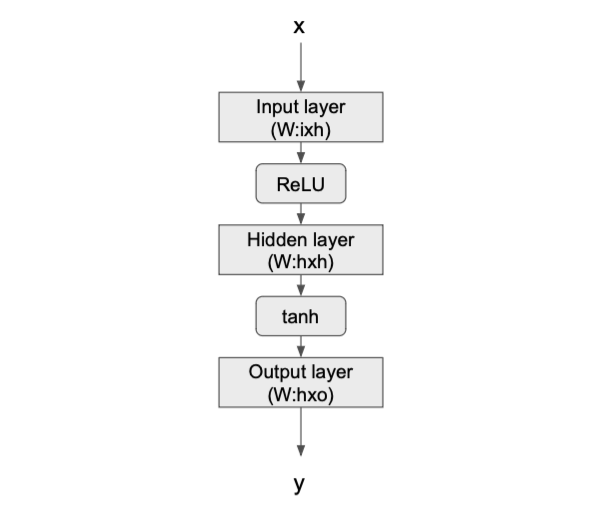

Train the model again and observe the accuracy, whether it is changed or not. Experiment with learning rates and ensure the model is converged.

In [38]:
## To-Do

import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Assume X (float32) and y (long) already exist from your cell
X = X.float()
y = y.long()

ds = TensorDataset(X, y)
dl = DataLoader(ds, batch_size=256, shuffle=True)

class MLP(nn.Module):
    def __init__(self, in_dim=2, h1=64, h2=64, h3=32, out_dim=3, p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            nn.ReLU(),                        # first hidden α
            nn.Linear(h1, h2),
            nn.Tanh(),                        # second hidden α (as in the prompt)
            nn.Linear(h2, h3),
            nn.ReLU(),                        # optional extra depth
            nn.Dropout(p),
            nn.Linear(h3, out_dim)            # logits for C classes
        )
    def forward(self, x): return self.net(x)

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-4)

def accuracy(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

epochs = 200
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    for xb, yb in dl:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*xb.size(0)

    # evaluate full-set accuracy
    model.eval()
    with torch.no_grad():
        logits = model(X)
        acc = accuracy(logits, y)
    if epoch % 20 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | loss {running_loss/len(ds):.4f} | acc {acc:.3f}")


epoch   1 | loss 1.0273 | acc 0.586
epoch  20 | loss 0.0323 | acc 0.994
epoch  40 | loss 0.0162 | acc 0.997
epoch  60 | loss 0.0142 | acc 0.992
epoch  80 | loss 0.0107 | acc 0.995
epoch 100 | loss 0.0089 | acc 0.995
epoch 120 | loss 0.0097 | acc 0.996
epoch 140 | loss 0.0102 | acc 0.997
epoch 160 | loss 0.0131 | acc 0.997
epoch 180 | loss 0.0098 | acc 0.999
epoch 200 | loss 0.0112 | acc 0.997


## (Optional) Regression

We will now demonstrate how to build a linear model and a neural network model for a regression task using PyTorch.  

In [17]:
import random
import torch
from torch import nn, optim
import math
from IPython import display
from plot_lib import plot_data, plot_model, set_default
from matplotlib import pyplot as plt

In [18]:
set_default()

Let's create a new data set.

In [19]:
seed = 1
random.seed(seed)
torch.manual_seed(seed)
N = 1000  # num_samples_per_class
D = 1  # dimensions
C = 1  # num_classes
H = 100  # num_hidden_units

In [20]:
X = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1)
y = X.pow(3) + 0.3 * torch.rand(X.size())

print("Shapes:")
print("X:", tuple(X.size()))
print("y:", tuple(y.size()))

Shapes:
X: (100, 1)
y: (100, 1)


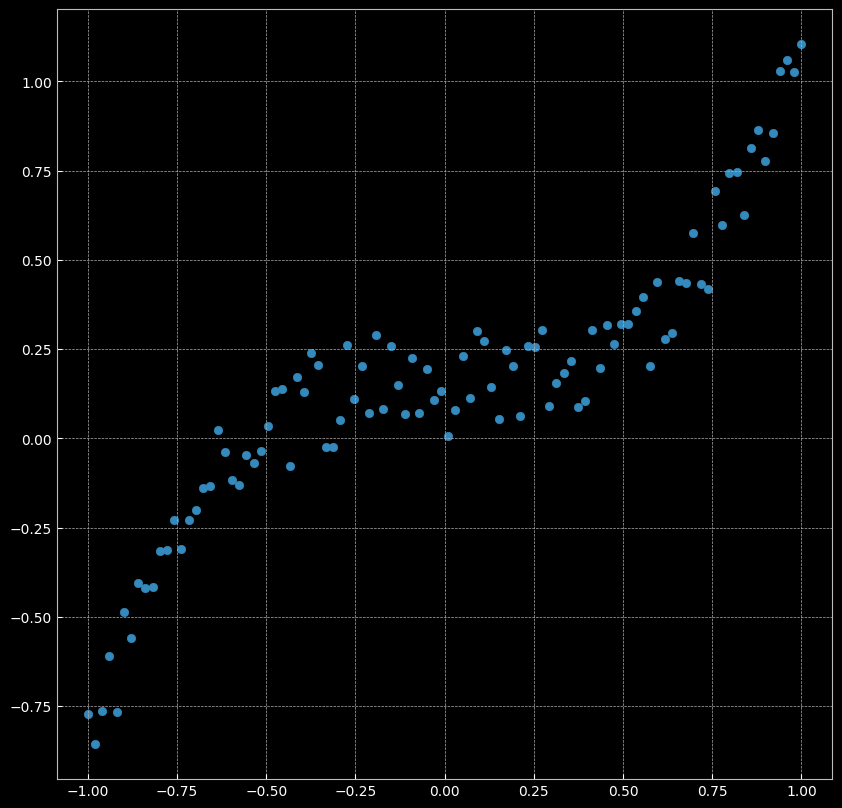

In [21]:
plt.scatter(X.cpu().numpy(), y.cpu().numpy())
plt.axis('equal');

### Linear model

Let's start again by creating a linear regression model to predict this function approximation. We can initialize the values of the hyper-parameters and create a Linear module with PyTorch as follows.

In [22]:
# Initialize hyper-parameters
learning_rate = 1e-3
steps = 1000

# nn package to create our linear model
# each Linear module has a weight and bias
model = nn.Sequential(
    nn.Linear(D, H),
    nn.Linear(H, C)
)

# print the model
print(model)

Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): Linear(in_features=100, out_features=1, bias=True)
)


Let's train our linear model using the training loop.

In [23]:
# we use MSE (mean squared error) loss from the nn package for our regression task
criterion = torch.nn.MSELoss()

# we use the optim package to apply stochastic gradient descent for our parameter updates
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # built-in L2

# Training loop
for t in range(1000):

    # forward pass over the model to get the logits (inputs to the loss function)
    y_pred = model(X)

    # Compute the loss (MSE)
    loss = criterion(y_pred, y)
    print("[EPOCH]: %i, [LOSS or MSE]: %.6f" % (t, loss.item()))
    display.clear_output(wait=True)

    # zero the gradients before running the backward pass
    optimizer.zero_grad()

    # Backward pass to compute the gradient of loss w.r.t our learnable params
    loss.backward()

    # Update params
    optimizer.step()

[EPOCH]: 999, [LOSS or MSE]: 0.029701


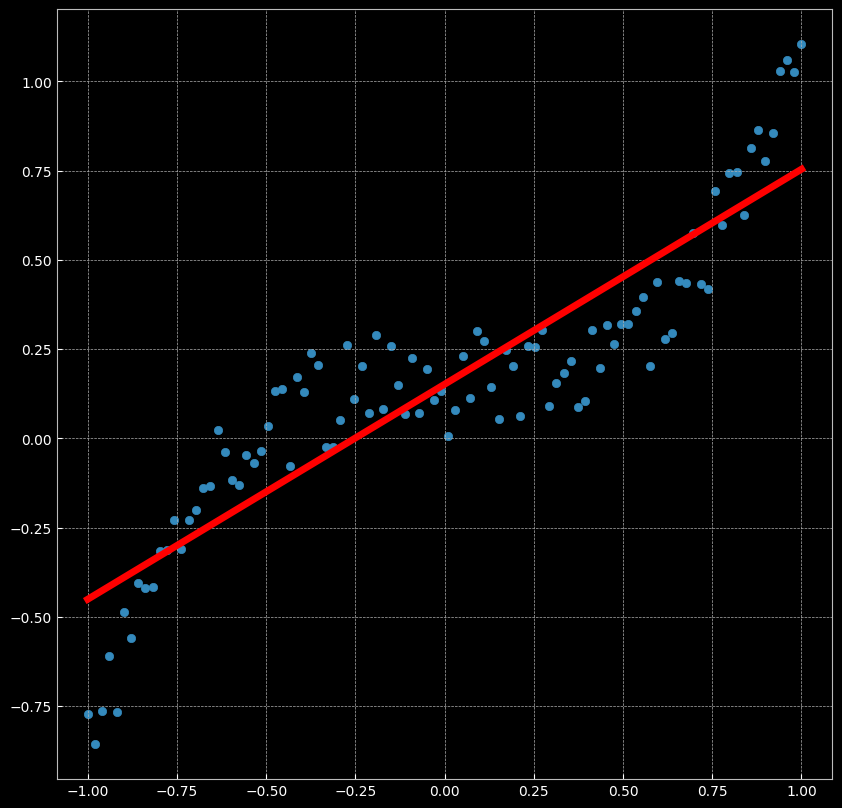

In [24]:
# Plot trained model
plt.scatter(X.data.cpu().numpy(), y.data.cpu().numpy())
plt.plot(X.data.cpu().numpy(), y_pred.data.cpu().numpy(), 'r-', lw=5)
plt.axis('equal');

Please take a moment to play with the values of the hyper-parameters and the value of H (number of hidden units) to observe the change in the models being learnt.

## Two-layer Network

Let's now implement a two layer multi-layer perceptron for the regression task. We will build 10 separate models, each with the same architecture but having different initial values of the parameters (weights and biases). This is to show the effect of local minima on model training.

Initialize the hyper-parameters:

In [25]:
learning_rate = 1e-3
steps = 1000

Create the models. Half of the models have ReLU activations and the other half have TanH activations.

In [26]:
# Number of networks
n_networks = 10
models = list()
y_pretrain = list()

# nn package also has different loss functions.
# we use MSE for a regression task
criterion = torch.nn.MSELoss()

for mod in range(n_networks):
    # nn package to create our linear model
    # each Linear module has a weight and bias
    model = nn.Sequential(
        nn.Linear(D, H),
        nn.ReLU() if mod < n_networks // 2 else nn.Tanh(),
        nn.Linear(H, C)
    )

    # Append models
    models.append(model)

Print the models:

In [27]:
print(models[0], models[-1])

Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=1, bias=True)
) Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=1, bias=True)
)


Create the training loop over the 10 models:

In [39]:
for mod in range(n_networks):
    # select the i-th model
    model = models[mod]

    # while we could simply use the stochastic gradient descent optimized, we will use the ADAM optimizer
    # because of its robustness and speed
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_l2) # built-in L2

    # Training loop
    for t in range(1000):

        # Feed forward to get the logits
        y_pred = model(X)

        # Append pre-train output
        if t == 0:
            y_pretrain.append(y_pred.detach())

        # Compute the loss and accuracy
        loss = criterion(y_pred, y)
        print(f"[MODEL]: {mod + 1}, [EPOCH]: {t}, [LOSS]: {loss.item():.6f}")
        display.clear_output(wait=True)

        # zero the gradients before running
        # the backward pass.
        optimizer.zero_grad()

        # Backward pass to compute the gradient
        # of loss w.r.t our learnable params.
        loss.backward()

        # Update params
        optimizer.step()

NameError: name 'lambda_l2' is not defined

### Predictions: Before Training

These are how the model predictions were before training:

RuntimeError: stack expects a non-empty TensorList

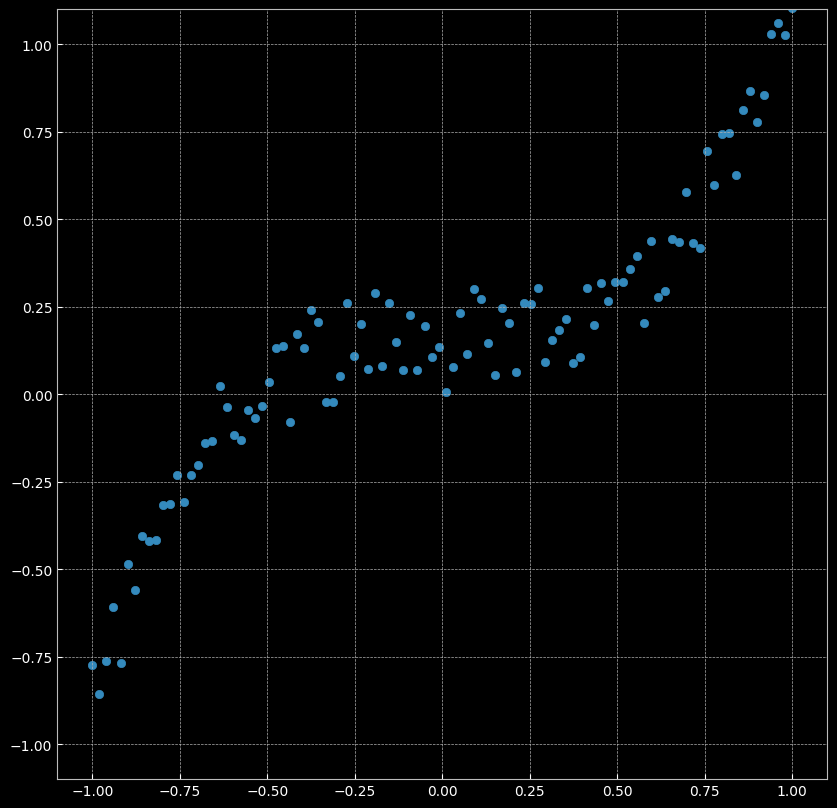

In [29]:
for y_pretrain_idx in y_pretrain:
    # New X that ranges from -5 to 5 instead of -1 to 1
    X_new = torch.unsqueeze(torch.linspace(-2, 2, 100), dim=1)

    plt.plot(X_new.numpy(), y_pretrain_idx.cpu().numpy(), 'r-', lw=1)

plt.scatter(X.cpu().numpy(), y.cpu().numpy(), label='data')
plt.axis('square')
plt.axis((-1.1, 1.1, -1.1, 1.1));
y_combo = torch.stack(y_pretrain)
plt.plot(X_new.numpy(), y_combo.var(dim=0).cpu().numpy(), 'g', label='variance');
plt.legend()

### Predictions: After Training

These features show how predictions changed after training:

In [ ]:
y_pred = list()
relu_models = models[:n_networks // 2]
tanh_models = models[n_networks // 2:]
plt.figure(figsize=(20, 10))

def dense_prediction(models, non_linearity, zoom):
    plt.subplot(1, 2, 1 if non_linearity == 'ReLU' else 2)
    for model in models:
        # New X that ranges from -5 to 5 instead of -1 to 1
        X_new = torch.unsqueeze(torch.linspace(-4, 4, 1001), dim=1)

        # Getting predictions from input
        with torch.no_grad():
            y_pred.append(model(X_new))

        plt.plot(X_new.cpu().numpy(), y_pred[-1].cpu().numpy(), 'r-', lw=1)
    plt.scatter(X.cpu().numpy(), y.cpu().numpy(), label='data')
    plt.axis('square')
    plt.axis(torch.tensor((-1.1, 1.1, -1.1, 1.1)) * zoom);
    y_combo = torch.stack(y_pred)
    plt.plot(X_new.cpu().numpy(), 10 * y_combo.var(dim=0).cpu().sqrt().numpy(), 'y', label='10 × std')
    plt.plot(X_new.cpu().numpy(), 10 * y_combo.var(dim=0).cpu().numpy(), 'g', label='30 × variance')
    plt.legend()
    plt.title(non_linearity + ' models')

z = 1  # try 1 or 4
dense_prediction(relu_models, 'ReLU', zoom=z)
dense_prediction(tanh_models, 'Tanh', zoom=z)

## (Optional) Exercise 2

Let's now revisit our weather forecasting application for NYC.

In [44]:
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd

class WeatherDataset(Dataset):
  def __init__(self, train_in, train_out):
        # Initialize data
        self.n_samples = train_in.shape[0]

        # here the first column is the class label, the rest are the features
        self.x_data = train_in # size [n_samples, n_features]
        self.y_data = train_out # size [n_samples, 1]

  # support indexing such that dataset[i] can be used to get i-th sample
  def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

  # we can call len(dataset) to return the size
  def __len__(self):
      return self.n_samples

def process_csv(filename):
  drive.mount('/content/drive')
  df = pd.read_csv(filename)

  # Filter data and apply normalization
  df = df.dropna()
  datatensor = torch.tensor(df.values[1:,1::].astype(float))
  datatensor = torch.nn.functional.normalize(datatensor)

  # Randomly select 80% of the examples for training,
  # remaining 20% will be for testing
  train, test = torch.utils.data.random_split(datatensor, [0.8, 0.2])
  traindata = torch.stack([t for t in train])
  testdata = torch.stack([t for t in test])

  # We can create separate tensors to input and output to the model
  train_in = torch.cat([traindata[:,0:2], traindata[:,3::]], dim=1)
  test_in = torch.cat([testdata[:,0:2], testdata[:,3::]], dim=1)
  train_out = traindata[:,2].unsqueeze(1) # we will use 3rd column as target prediction
  test_out = testdata[:,2].unsqueeze(1)
  train_out = (train_out > 0).double()
  test_out = (test_out > 0).double()
  return train_in, train_out, test_in, test_out

def train(model, loss, optimizer, \
          trainingData, \
          learning_rate, steps, batch_size):

  loader = iter(DataLoader(dataset=trainingData, batch_size=batch_size, shuffle=True))

  losses = []; step = 0
  for step in range(0, steps):
    input, target = next(loader)
    optimizer.zero_grad() # reset gradiant value to zero
    model.double()
    output = model(input) # pass input to model
    err = loss(output, target) # compute mean squared error between model prediction and target value
    err.backward() # evaluate the gradient
    optimizer.step() # propagate the evaluated gradient to update parameters

    print('step {step}, loss {err.item()}')
    display.clear_output(wait=True)

Now let's define a multi-layer perceptron for our rain prediction task.

In [45]:
## To-Do: Define a Network with 1 input, 1 hidden and 1 output layer.
D = 8
H = 100
C = 1

# model = ..

We will use the new model for prediction the probability of rain.

In [46]:
# Load the data
dataset = '/content/drive/MyDrive/ML473/recitation/NYC_Weather_2016_2022.csv'
train_in, train_out, test_in, test_out = process_csv(dataset)
trainingData = WeatherDataset(train_in, train_out)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:

# Initialize hyper-parameters
learning_rate = 0.5
steps = 150
batch_size = 128


In [52]:
# Define loss and optimizer
loss = torch.nn.BCEWithLogitsLoss()

In [53]:


optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [54]:


# Train
train(model, loss, optimizer, trainingData, learning_rate, steps, batch_size)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x8 and 2x64)

In [47]:


with torch.no_grad(): # this signal informs torch that further operations will not need the gradient computation
  model_output = model(test_in)
  predictions = (model_output > 0.5)

  print("Accuracy of prediction is: ", torch.sum(predictions == test_out)/test_out.shape[0])
  precision = torch.logical_and(predictions, test_out).sum() / (predictions == 1).sum()
  recall = torch.logical_and(predictions, test_out).sum() / (test_out == 1).sum()
  print("Precision: ", precision)
  print("Recall: ", recall)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x8 and 1x100)

[step 100] loss=0.0646 acc=0.996
[step 200] loss=0.0371 acc=0.997
[step 300] loss=0.0179 acc=0.997


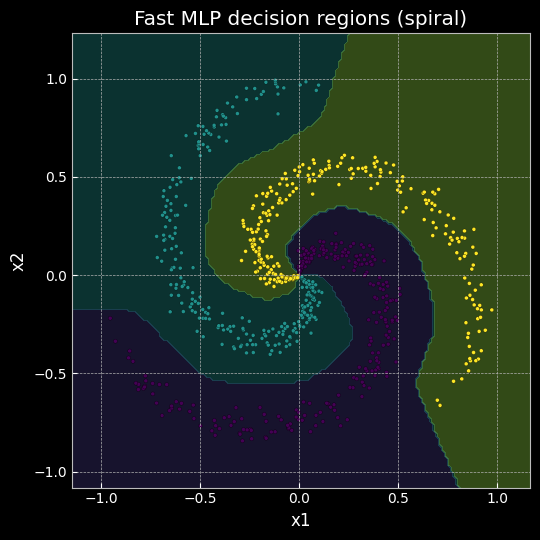

In [48]:
# Fast spiral separator (ReLU MLP) — ~5–10s on CPU in Colab
import math, torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- Make a small 3-arm spiral quickly ---
def make_spiral(n_per_class=250, classes=3, noise=0.20, seed=123):
    torch.manual_seed(seed)
    X = torch.zeros(n_per_class*classes, 2)
    y = torch.zeros(n_per_class*classes, dtype=torch.long)
    for c in range(classes):
        t = torch.linspace(0, 1, n_per_class)
        inner = torch.linspace((2*math.pi/classes)*c, (2*math.pi/classes)*(2+c), n_per_class) + torch.randn(n_per_class)*noise
        for i in range(n_per_class):
            X[c*n_per_class + i] = t[i]*torch.tensor([math.sin(inner[i]), math.cos(inner[i])], dtype=torch.float32)
            y[c*n_per_class + i] = c
    perm = torch.randperm(len(X))
    return X[perm], y[perm]

X, y = make_spiral()

# --- Compact MLP that works fast ---
model = nn.Sequential(
    nn.Linear(2, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 3)
)
for m in model:
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

criterion = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loader = DataLoader(TensorDataset(X, y), batch_size=128, shuffle=True)

# --- Train (short & sweet) ---
steps = 300
for step in range(1, steps+1):
    for xb, yb in loader:
        logits = model(xb)
        loss = criterion(logits, yb)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    if step % 100 == 0 or step == steps:
        with torch.no_grad():
            acc = (model(X).argmax(1) == y).float().mean().item()
        print(f"[step {step}] loss={loss.item():.4f} acc={acc:.3f}")

# --- Plot decision regions ---
with torch.no_grad():
    x_min, x_max = X[:,0].min().item(), X[:,0].max().item()
    y_min, y_max = X[:,1].min().item(), X[:,1].max().item()
    cx, cy = (x_min+x_max)/2, (y_min+y_max)/2
    w = max(x_max-x_min, y_max-y_min)*1.2
    x_min, x_max = cx - w/2, cx + w/2
    y_min, y_max = cy - w/2, cy + w/2
    res = 160
    xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, res), torch.linspace(y_min, y_max, res), indexing="xy")
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
    Z = model(grid).argmax(1).reshape(res, res).numpy()

plt.figure(figsize=(5.5,5.5))
plt.contourf(xx.numpy(), yy.numpy(), Z, alpha=0.35, levels=np.arange(4)-0.5)
plt.scatter(X[:,0].numpy(), X[:,1].numpy(), c=y.numpy(), s=8, edgecolor='k', linewidth=0.2)
plt.title("Fast MLP decision regions (spiral)")
plt.xlabel("x1"); plt.ylabel("x2"); plt.tight_layout(); plt.show()
